In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import numpy as np

[  20000.   40000.   60000.   80000.  100000.  120000.  140000.  160000.
  180000.  200000.  220000.  240000.  260000.  280000.  300000.  320000.
  340000.  360000.  380000.  400000.  420000.  440000.  460000.  480000.
  500000.  520000.  540000.  560000.  580000.  600000.  620000.  640000.
  660000.  680000.  700000.  720000.  740000.  760000.  780000.  800000.
  820000.  840000.  860000.  880000.  900000.  920000.  940000.  960000.
  980000. 1000000. 1020000. 1040000. 1060000. 1080000. 1100000. 1120000.
 1140000. 1160000. 1180000. 1200000.]


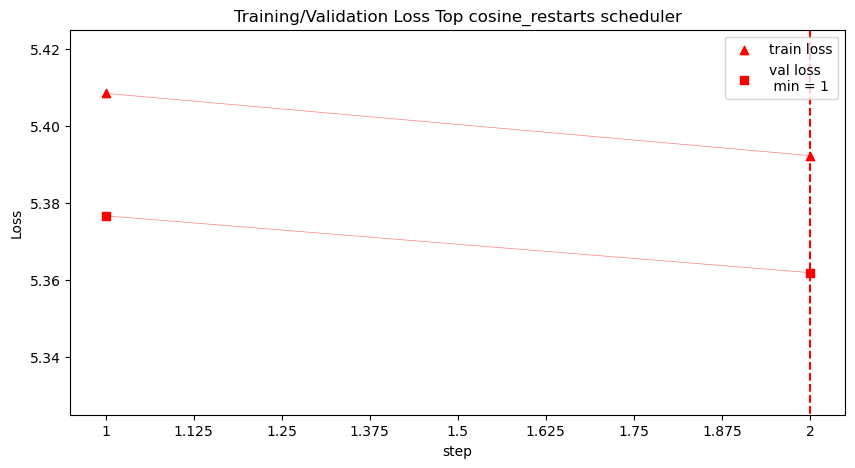

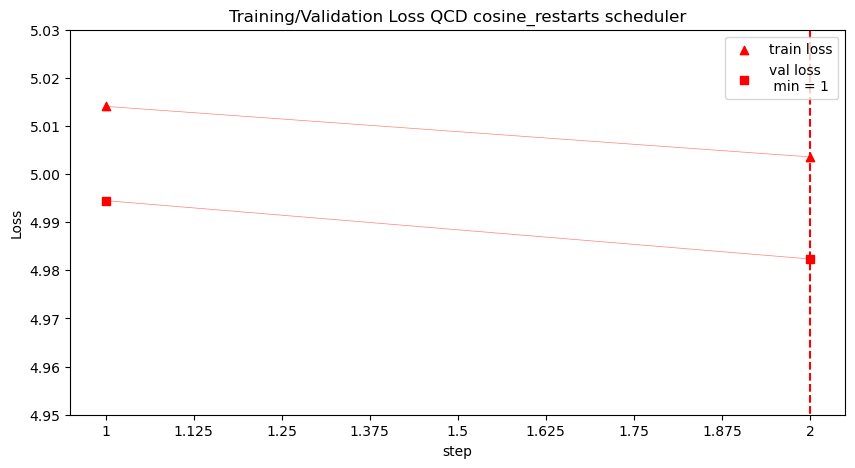

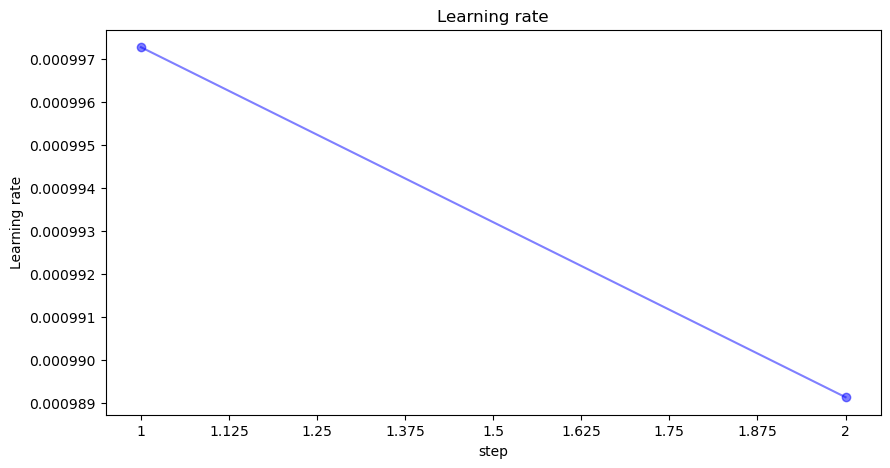

In [2]:
DATASET = "JETCLASS"
SCHEDULER = "cosine_restarts"
N_JETS = 10000000

BATCH_SIZE = 500
EPOCH_STEPS = N_JETS / BATCH_SIZE
NUM_EPOCHS = 60

EPOCHS = np.linspace(EPOCH_STEPS, EPOCH_STEPS*NUM_EPOCHS, NUM_EPOCHS )

print(EPOCHS)

#modify name for specific traings run
folder = f"/hpcwork/rwth0934/hep_foundation_model/training/{DATASET}_{N_JETS}_{SCHEDULER}_50_untrained"

qcd = pd.read_csv(f"{folder}/QCD_training_log.csv")
top = pd.read_csv(f"{folder}/TTBar_training_log.csv")

top_min = np.argmin(top["val_loss"])
qcd_min = np.argmin(qcd["val_loss"])

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(top["step"], top["train_loss"], label="train loss",
           color = "red",
           marker = "^")
ax.scatter(top["step"], top["val_loss"], label=f"val loss \n min = {top_min}",
           color = "red",
           marker = "s")

ax.plot(top["step"], top["train_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)
ax.plot(top["step"], top["val_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)

ax.vlines(top["step"][top_min], 0, 10, color = "red", linestyles="--")

ax.legend()

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/20000:g}")
)

#ax.set_yscale("log")
ax.set_title(f"Training/Validation Loss Top {SCHEDULER} scheduler")

#ax.set_xlim(0.2, 20)
ax.set_ylim(5.325, 5.4250)
ax.set_xlabel("step")
ax.set_ylabel("Loss")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(qcd["step"], qcd["train_loss"], label="train loss",
           color = "red",
           marker = "^")
ax.scatter(qcd["step"], qcd["val_loss"], label=f"val loss \n min = {qcd_min}",
           color = "red",
           marker = "s")

ax.plot(qcd["step"], qcd["train_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)
ax.plot(qcd["step"], qcd["val_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)

ax.vlines(qcd["step"][qcd_min], 0, 10, color = "red", linestyles="--")

ax.legend()

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/20000:g}")
)

#ax.set_yscale("log")
ax.set_title(f"Training/Validation Loss QCD {SCHEDULER} scheduler")

#ax.set_xlim(0.2, 20)
ax.set_ylim(4.95, 5.03)
ax.set_xlabel("step")
ax.set_ylabel("Loss")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(qcd["step"], qcd["lr"], color = "blue", alpha = 0.5)
ax.scatter(qcd["step"], qcd["lr"], color = "blue", alpha = 0.5)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/20000:g}")
)

ax.set_xlabel("step")
ax.set_ylabel("Learning rate")

ax.set_title("Learning rate")

plt.show()